# IMDB Review
- Movie Reviews dataset

### End to End Deep Learning Project Using Simple RNN
![Screenshot 2026-05-23 123020.png](<attachment:Screenshot 2026-05-23 123020.png>)
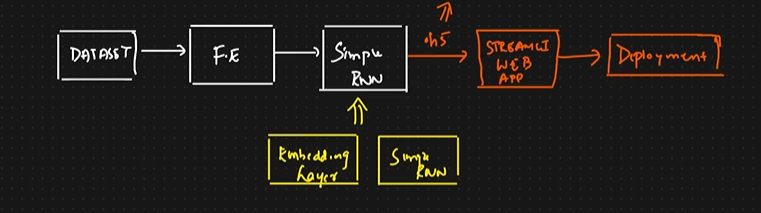

# Libaries

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.layers import Embedding , SimpleRNN , Dense

# Loading the Dataset

In [3]:
max_features = 10000                        # This is our maximum vocabluary size , IT is taken large so that after the hashing of the words the collision rate will be so less.
(X_train , Y_train),(X_test , Y_test) = imdb.load_data(num_words = max_features)

print(f"The Training Dataset Shape for Input Features : {X_train.shape} , For Output Labels : {Y_train.shape}")
print(f"The Testing Dataset Shape for Input Features: {X_test.shape} , For Output Labels: {Y_test.shape}")

The Training Dataset Shape for Input Features : (25000,) , For Output Labels : (25000,)
The Testing Dataset Shape for Input Features: (25000,) , For Output Labels: (25000,)


# Inspecting the Data
- Observation --> The Dataset is directly decoded in such a way that it is already having all the indexs as the value instead of words

In [4]:
X_train[0]                          # This is the onehot representation of the every word done using the index and the hashing function , instead of just zeros and ones
# The size will be 10000 as our vocab size is 10000 and each and every index represents a word

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [5]:
Y_train.view()                      # As it is the label column it will be having either zero or one

array([1, 0, 0, ..., 0, 1, 0], shape=(25000,))

In [6]:
sample_review = X_train[0] 
sample_label = Y_train[0]
print(f"Sample review (as integers): {sample_review}")
print(f"Sample labels (as integers): {sample_label}")

Sample review (as integers): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
Sample labels (as integers): 1


### Mapping
- Lets map the indexs back to the original words

In [7]:
word_index = imdb.get_word_index()
word_index

# From this we will be getting all the words with their particular indexs in the form of dictionary

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

- Reversing the dictionary so that , we can access the values of the index

In [8]:
reverse_word_index = {value : key for key , value in word_index.items()}
reverse_word_index

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

- Decoded Review

In [9]:
decoded_review = ' '.join([reverse_word_index.get(i - 3 , '?') for i in sample_review])
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

---------------------------------------------------------------------------------------------------------------------------------------------------------------

# Padding 
- Making all the word vectors of the same lenght
- By default the Pre-Pruning is applied to the transfromation

In [10]:
max_len = 500

X_train = sequence.pad_sequences(X_train , maxlen = max_len)
X_test = sequence.pad_sequences(X_test , maxlen = max_len)

X_train[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

# Simple RNN

In [11]:
model = Sequential([
    tf.keras.layers.Input(shape = (max_len,)),           # giving the inputs explicity so that we can check the build of the model
    Embedding(max_features , 128 ),                     # It is the Embedding layer which will have the Embedding vector matrix of dimension 10000 x 128
    SimpleRNN(128,activation = 'relu'),                 # Simple RNN single layer of RNN is used with 128 neurons init , with activation function relu
    Dense(1,activation = 'sigmoid')                     # Finally a Dense layer is used for getting the output as the problem statement is binary classification , the output layer's activation function is sigmoid
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,025 (5.01 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

### EarlyStopping callbacks

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(monitor='val_loss' , patience=10 , restore_best_weights=True)
early

In [13]:
model.compile(loss = 'binary_crossentropy' , optimizer= 'adam' , metrics = ['accuracy'])
history = model.fit(X_train , Y_train , validation_split = 0.2 , batch_size = 32 , callbacks = [early] , epochs = 5)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 104ms/step - accuracy: 0.6671 - loss: 0.6004 - val_accuracy: 0.7398 - val_loss: 0.5126
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 103ms/step - accuracy: 0.8134 - loss: 0.4429 - val_accuracy: 0.5840 - val_loss: 0.6665
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 105ms/step - accuracy: 0.5962 - loss: 4260868864.0000 - val_accuracy: 0.6234 - val_loss: 0.6617
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.6169 - loss: 192516587520.0000 - val_accuracy: 0.6322 - val_loss: 0.7097
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.6826 - loss: 0.6127 - val_accuracy: 0.6358 - val_loss: 0.6879


In [14]:
model.save('simple_rnn_model.h5')

In [15]:
from tensorflow.keras.models import load_model

trained = load_model('simple_rnn_model.h5')
trained.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,027 (5.01 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [16]:
trained.get_weights()

[array([[ 0.02840023,  0.13912472, -0.07628245, ..., -0.08553018,
         -0.1048153 ,  0.03848174],
        [ 0.00402533, -0.0038146 , -0.02987227, ..., -0.05447647,
         -0.00439834, -0.07043622],
        [ 0.0399695 ,  0.01385327, -0.00425135, ...,  0.03605747,
         -0.06342907,  0.06948315],
        ...,
        [-0.01274231, -0.00706554, -0.02037505, ..., -0.02667385,
          0.01112197,  0.04666091],
        [-0.012254  , -0.01882094,  0.0629589 , ...,  0.02339655,
         -0.025064  ,  0.04237122],
        [-0.04465511,  0.01148409,  0.05318593, ...,  0.06173708,
         -0.02236287, -0.00261927]], shape=(10000, 128), dtype=float32),
 array([[-0.10925489, -0.11311346,  0.14608255, ...,  0.06689791,
          0.19447604, -0.09493569],
        [ 0.01570101,  0.03590001, -0.08577483, ...,  0.00416605,
         -0.07305901, -0.14808509],
        [ 0.07450585,  0.0776218 ,  0.15567283, ..., -0.04158356,
          0.07278142, -0.14614207],
        ...,
        [ 0.0623240

In [20]:
def preprocess_test(text):
    words = text.lower().split()
    sample_review_encoded = [word_index.get(word , 2)+3 for word in words]
    padded_review = sequence.pad_sequences([sample_review_encoded] , maxlen = 500)
    return padded_review

# ##
def decoded_review(encoded_review):
    return ' '.join([reverse_word_index.get(i-3 , '?') for i in sample_review])

In [21]:
def predict_review(review):
    preprocessed_input = preprocess_test(review)
    Y_pred = trained.predict(preprocessed_input)
    sentiment = 'Positive' if Y_pred[0][0] > 0.5 else 'Negative'
    return sentiment , Y_pred[0][0]
    

In [22]:
test_review = "The movie was fanstatic the acting was great and the plot was thrillig "
sent , score = predict_review(test_review)

print(f'Review: {test_review}')
print(f'Sentiment: {sent}')
print(f'Score: {score}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
Review: The movie was fanstatic the acting was great and the plot was thrillig 
Sentiment: Positive
Score: 0.6730121374130249
